# Day 4 Walkthrough: What A Transformer Reads

The first two days worked on tables, where every value arrived in a column with
a name. Yesterday the data was a grid of brightnesses. Today it is prose, and a
document does not fit in a column at all. A discharge summary has no fixed
length, no fields, and no schema, and the quantity somebody wants from it is a
sentence buried somewhere inside it.

That is the subject of this hour. A pre-trained transformer will read this text
for us, and the whole of the rest of the day depends on understanding two
things about it: what it actually receives when you hand it a document, and
what it is doing when it learns.

The data is 200 anonymized discharge summaries of sepsis admissions from a
Brazilian teaching hospital, each written in Portuguese and translated into
English by the people who published them.

| Section | Minutes |
| --- | --- |
| Orientation | 3 |
| 1. A Document Is Not A Row | 7 |
| 2. What The Model Actually Reads | 12 |
| 3. A Pre-trained Model Already Has Opinions | 8 |
| 4. From A Frozen Encoder Back To Day 1's Classifier | 15 |
| 5. A Falling Loss Is Not A Working Model | 11 |
| 6. What To Take Away | 4 |

## Orientation (3 Minutes)

The habits from the first three days still apply. Restart the kernel and run
every cell in order if anything stops making sense, read the shape and the
range before trusting an array, and print a baseline next to every number you
intend to interpret. That last one earns its keep twice today.

One thing is genuinely new, and it is worth saying out loud before the first
cell runs. **Today reaches the network.** Days 1 to 3 read every byte they
needed from the `data` directory. Today the models come from the Hugging Face
Hub, which means a download the first time each one is used, and it means the
notebook depends on a service outside this room.

Two consequences follow. Every model below is pinned by name and by revision,
because a name alone identifies whatever the Hub is serving today rather than
what these results were measured against. And the download is cached, so the
first run of a cell is slow and every later run is not.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from transformers.utils import logging as hf_logging

# Every notebook resolves its data through a path relative to itself, so the
# materials work the same way on JupyterHub and on a laptop.
DATA_DIR = Path.cwd().parent / "data"

RANDOM_STATE = 42

# A model name on its own names whatever the Hub is serving today. The revision
# is the commit these numbers were measured against.
SMALL_MODEL = "distilbert/distilbert-base-uncased"
SMALL_REVISION = "12040accade4e8a0f71eabdb258fecc2e7e948be"
CLINICAL_MODEL = "emilyalsentzer/Bio_ClinicalBERT"
CLINICAL_REVISION = "d5892b39a4adaed74b92212a44081509db72f87b"


def pick_device():
    """Use a GPU when the image provides one, and fall back sensibly."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()

# transformers draws a progress bar while it loads a model's weights, and warns
# whenever a document is longer than the model accepts. Neither survives as
# readable output, so both are turned off. Section 2 measures the length limit
# directly rather than relying on that warning. A download on a cold cache
# still reports its own progress, which is worth seeing the first time.
hf_logging.disable_progress_bar()
hf_logging.set_verbosity_error()

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)

print("Reading data from:", DATA_DIR)
print("PyTorch:", torch.__version__, "| running on:", DEVICE)

Reading data from: /Users/dimitar.peshevski/workspace/ml-workshop/Day 4 - Text Processing and Analysis/data
PyTorch: 2.11.0 | running on: mps


## 1. A Document Is Not A Row (7 Minutes)

Read the index first, as always.

In [2]:
summaries = pd.read_csv(DATA_DIR / "discharge_summaries.csv")

print("Rows:", len(summaries))
print("Columns:", list(summaries.columns))
summaries[["record_id", "outcome_en", "length_of_stay", "icu"]].head()

Rows: 200
Columns: ['record_id', 'summary_pt', 'summary_en', 'diagnosis_pt', 'diagnosis_en', 'outcome_pt', 'outcome_en', 'length_of_stay', 'specialties', 'icu', 'palliative_care']


,record_id,outcome_en,length_of_stay,icu
0,1,alive,99999 {1},1
1,2,alive,55,1
2,3,alive,95,1
3,4,death,15,1
4,5,alive,4,0


Eleven columns, of which two hold the document itself, in Portuguese and in
English. The rest are the structured facts the hospital recorded about the same
admission.

Look at those structured columns for a moment before moving on. `outcome_en`
holds what should be a two-valued fact, `length_of_stay` should be a number,
and `icu` should be a flag. Print what is actually in them.

In [3]:
for column in ["outcome_en", "icu"]:
    counts = summaries[column].value_counts(dropna=False)
    print(f"{column}: {len(counts)} distinct values")
    print(counts.to_string())
    print()

# length_of_stay is mostly plain numbers, so the odd ones do not reach the top
# of a value_counts and have to be asked for.
stay = summaries["length_of_stay"].astype(str)
odd = stay[~stay.str.fullmatch(r"[0-9]+")]
print(f"length_of_stay: {len(odd)} of {len(stay)} rows hold something other "
      "than a plain number, and these are the values they hold")
print(sorted(odd.unique(), key=len))

outcome_en: 7 distinct values
outcome_en
alive                 102
death                  50
alive {transfer}       25
{death}                11
{alive}                 8
{alive} {transfer}      3
alive {death}           1

icu: 6 distinct values
icu
0        92
1        51
0 {1}    36
{1}      11
NaN       6
{0}       4

length_of_stay: 24 of 200 rows hold something other than a plain number, and these are the values they hold
['{7}', '{4}', '{1}', '{49}', '{61}', '{10}', '{13}', '{82}', '{21}', '{15}', '{17}', '{62}', '{51}', '{34}', '{36}', '{52}', '{20}', '{46}', '{44}', '{33}', '99999 {1}', '99999 {14}', '99999 {130}']


None of the three is clean, and the braces are not a loading error. They are in
the file. Somebody wrote them deliberately, and working out what they mean is
the first task of the laboratory exercise this afternoon, so leave them alone
for now.

What matters for this hour is the document. Here is one, in the shape the model
will get it.

In [4]:
example = summaries.loc[summaries["record_id"] == 2].iloc[0]
text = example["summary_en"]

print(f"record {example['record_id']}: {len(text)} characters, "
      f"{len(text.split())} words\n")
print("--- the first 500 characters " + "-" * 40)
print(text[:500])
print("\n--- the last 500 characters " + "-" * 41)
print(text[-500:])

record 2: 5409 characters, 749 words

--- the first 500 characters ----------------------------------------
1. bloodstream infection associated with Schilley catheter in the right femoral vein sac 11/08 2. bacterial endocarditis associated with catheter echocardiogram 11/18: presence of vegetation in the mitral valve 3. pyogenic spondylodiscitis in l3/l4 11/05: low back pain, gait disturbance, computed tomography of the lumbosacral spine 11/12: findings suggestive of a fracture due to bone fragility of the vertebral body of l1, gas foci in the spinal canal at the level of l2l3 that may be related to a

--- the last 500 characters -----------------------------------------
p for amyloidosis investigation: [person] missed a follow-up appointment appointment on 09/09, scheduled for 01/13 for motor rehabilitation. We are awaiting an appointment by the physiatry department at [organization] requested on 12/27. Check the nuclear magnetic resonance report of the pelvis from 12/16. Previous chr

Read the two ends against each other, because the shape of the document is the
point. It opens with an administrative preamble, giving the sex, the age, the
date, the length of the stay, and the ward. Then it becomes a narrative, and
the narrative runs forward in time.

That is what a discharge summary is. A doctor writes it at the end of an
admission, describing the admission in the order it happened.

Now the lengths, over all 200.

words per document
count     200.0
mean      599.0
std       299.0
min       119.0
25%       386.0
50%       540.0
75%       734.0
max      1601.0


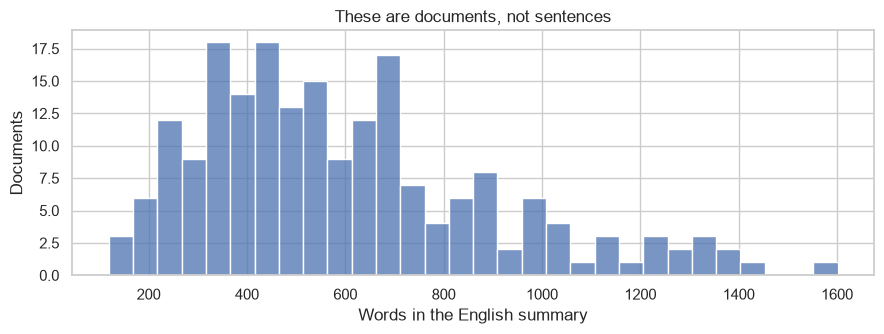

In [5]:
word_counts = summaries["summary_en"].str.split().str.len()

print("words per document")
print(word_counts.describe().round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(word_counts, bins=30, ax=ax)
ax.set_xlabel("Words in the English summary")
ax.set_ylabel("Documents")
ax.set_title("These are documents, not sentences")
plt.tight_layout()
plt.show()

A median of about 540 words and a tail running past 1500. For comparison, the
whole of this markdown cell is under a hundred words. These are not the one
line reviews that text classification examples usually use.

Hold on to the word count, because the next section is about the fact that the
model does not count words.

## 2. What The Model Actually Reads (12 Minutes)

A transformer does not receive characters and it does not receive words. It
receives integers, one per token, where a token is a unit from a fixed
vocabulary that was chosen before the model was trained.

Load the tokeniser and look at what it does to an ordinary sentence.

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(SMALL_MODEL, revision=SMALL_REVISION)

sentence = "The patient was admitted with severe sepsis and acute renal failure."
pieces = tokenizer.tokenize(sentence)

print(sentence)
print()
print(pieces)
print()
print(f"{len(sentence.split())} words became {len(pieces)} tokens.")

The patient was admitted with severe sepsis and acute renal failure.

['the', 'patient', 'was', 'admitted', 'with', 'severe', 'sep', '##sis', 'and', 'acute', 'renal', 'failure', '.']

11 words became 13 tokens.


Most words survive whole. Two do not, and the `##` prefix marks a piece that
continues the word before it, so `sep` plus `##sis` is one word spelled in two
tokens.

This is called WordPiece, and the rule is simple: keep the longest piece that
is in the vocabulary, then start again on what is left. A word that is in the
vocabulary costs one token, and a word that is not gets spelled out.

The vocabulary here was built from English Wikipedia and a corpus of books. Ask
what that means for clinical writing.

In [7]:
for word in ["sepsis", "septicemia", "tracheostomy", "norepinephrine",
             "thrombocytopenia", "acalasia"]:
    print(f"{word:<18} -> {tokenizer.tokenize(word)}")

sepsis             -> ['sep', '##sis']
septicemia         -> ['sept', '##ice', '##mia']
tracheostomy       -> ['tr', '##ache', '##ost', '##omy']
norepinephrine     -> ['nor', '##ep', '##ine', '##ph', '##rine']
thrombocytopenia   -> ['th', '##rom', '##bo', '##cy', '##top', '##enia']
acalasia           -> ['ac', '##ala', '##sia']


Six words, and between two and six tokens each. Nothing is broken. The
vocabulary simply has no entry for a word that a general corpus never contains,
so it falls back on spelling.

That has a cost, and the cost is measurable. Compare an ordinary English
paragraph against these documents.

In [8]:
ORDINARY = (
    "The first two days of this workshop worked on tables, where every value "
    "arrived in a column with a name. Yesterday the data was a grid of "
    "brightnesses. Today it is prose, and a document does not fit in a column "
    "at all. A sentence has no fixed length, and the model that reads it can "
    "only accept a fixed number of pieces at a time."
)


def tokens_per_word(texts):
    """How many tokens the tokeniser spends on each word, on average."""
    counts = [(len(tokenizer.tokenize(t)), len(t.split())) for t in texts]
    return sum(t for t, _ in counts) / sum(w for _, w in counts)


print(f"an ordinary English paragraph   {tokens_per_word([ORDINARY]):.2f} "
      "tokens per word")
print(f"the English summaries           "
      f"{tokens_per_word(summaries['summary_en']):.2f} tokens per word")
print(f"the Portuguese originals        "
      f"{tokens_per_word(summaries['summary_pt']):.2f} tokens per word")

an ordinary English paragraph   1.12 tokens per word
the English summaries           1.81 tokens per word


the Portuguese originals        2.56 tokens per word


Clinical English costs about half again as much as ordinary English, and the
Portuguese costs more than twice as much. The Portuguese figure has a second
cause on top of the first, which is that this vocabulary is not in that
language at all, so almost every word is spelled rather than looked up.

So a word count understates how much of a clinical document a model has to
process. Now the reason that matters.

In [9]:
print("the tokeniser's stated limit:", tokenizer.model_max_length, "positions")
print("two of those hold the [CLS] and [SEP] markers, so a document")
print("gets at most 510 tokens of its own.\n")

token_counts = summaries["summary_en"].apply(
    lambda t: len(tokenizer.tokenize(t)))

print("tokens per document")
print(token_counts.describe().round(0).to_string())
print()
print(f"documents needing more than 510 tokens: {(token_counts > 510).sum()}"
      f" of {len(token_counts)}")
kept = np.minimum(token_counts, 510) / token_counts
print(f"fraction of a document that fits, median: {kept.median():.2f}")

the tokeniser's stated limit: 512 positions
two of those hold the [CLS] and [SEP] markers, so a document
gets at most 510 tokens of its own.

tokens per document
count     200.0
mean     1084.0
std       550.0
min       211.0
25%       698.0
50%       968.0
75%      1333.0
max      3331.0

documents needing more than 510 tokens: 177 of 200
fraction of a document that fits, median: 0.53


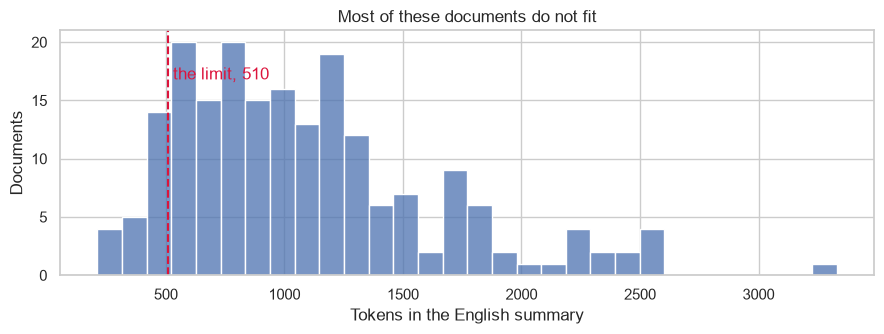

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(token_counts, bins=30, ax=ax)
ax.axvline(510, color="crimson", linestyle="--")
ax.text(530, ax.get_ylim()[1] * 0.8, "the limit, 510", color="crimson")
ax.set_xlabel("Tokens in the English summary")
ax.set_ylabel("Documents")
ax.set_title("Most of these documents do not fit")
plt.tight_layout()
plt.show()

The median document needs 968 tokens and the model accepts 510, so about half
of a typical summary cannot be passed in at all. That is not a warning that
will appear at runtime. Something has to be discarded, and the tokeniser
discards it silently.

Which half gets discarded is a setting, and it is worth seeing the mechanism on
something small enough to read.

In [11]:
toy = "one two three four five six seven eight"

for side in ["right", "left"]:
    tokenizer.truncation_side = side
    ids = tokenizer(toy, truncation=True, max_length=5)["input_ids"]
    print(f"truncation_side={side!r:<8} -> "
          f"{tokenizer.convert_ids_to_tokens(ids)}")

# Put it back, so nothing later in the notebook inherits a changed setting.
tokenizer.truncation_side = "right"
print(f"\nthe default is {tokenizer.truncation_side!r}, which keeps the "
      "beginning.")

truncation_side='right'  -> ['[CLS]', 'one', 'two', 'three', '[SEP]']
truncation_side='left'   -> ['[CLS]', 'six', 'seven', 'eight', '[SEP]']

the default is 'right', which keeps the beginning.


`truncation=True` on its own keeps the start of a sequence and throws away the
end, because `truncation_side` defaults to `"right"`. Setting it to `"left"`
does the opposite.

That is the whole of the mechanism. Remember that it exists.

## 3. A Pre-trained Model Already Has Opinions (8 Minutes)

Nothing so far has involved the model, only its tokeniser. Before training
anything, it is worth asking what a pre-trained model already knows, because
"pre-trained" is doing a lot of work in every sentence anybody writes about
these systems.

DistilBERT was trained by hiding a word and asking it to guess the word. That
task is still available, so we can simply ask it.

In [12]:
from transformers import pipeline

unmasker = pipeline("fill-mask", model=SMALL_MODEL, revision=SMALL_REVISION,
                    device=DEVICE)

PROMPTS = [
    "The patient developed septic [MASK].",
    "Blood cultures were positive for [MASK].",
    "The patient was treated with intravenous [MASK].",
]

for prompt in PROMPTS:
    guesses = unmasker(prompt, top_k=4)
    print(prompt)
    print("   ", ", ".join(f"{g['token_str']} {g['score']:.3f}"
                           for g in guesses))

The patient developed septic [MASK].
    arthritis 0.272, problems 0.050, syndrome 0.042, pneumonia 0.041
Blood cultures were positive for [MASK].
    hiv 0.309, cancer 0.067, tuberculosis 0.033, diabetes 0.020
The patient was treated with intravenous [MASK].
    injection 0.272, antibiotics 0.122, fluids 0.122, saline 0.086


Ask the room to read the first line before the second. A clinician completing
"septic ..." says shock. DistilBERT does not, and it puts something else first
by a wide margin.

The second line is worse, and worth stating plainly: a blood culture cannot
detect HIV. It is a test that grows bacteria and fungi.

The model is not broken and it is not lying. It learned English from Wikipedia
and books, where "septic" stands next to a tank far more often than next to a
shock, and where "positive for" is followed by whatever a general corpus talks
about. It is answering the question it was trained on, and that question was
never about medicine.

Here is the same three prompts given to a model that was trained further on
clinical notes.

In [13]:
clinical = pipeline("fill-mask", model=CLINICAL_MODEL,
                    revision=CLINICAL_REVISION, device=DEVICE)

for prompt in PROMPTS:
    print(prompt)
    for name, model in [("general ", unmasker), ("clinical", clinical)]:
        guesses = model(prompt, top_k=3)
        print(f"    {name}  " + ", ".join(f"{g['token_str']} {g['score']:.3f}"
                                          for g in guesses))
    print()

The patient developed septic [MASK].
    general   arthritis 0.272, problems 0.050, syndrome 0.042
    clinical  shock 0.944, physiology 0.024, picture 0.018

Blood cultures were positive for [MASK].
    general   hiv 0.309, cancer 0.067, tuberculosis 0.033
    clinical  yeast 0.554, flu 0.282, pneumonia 0.041

The patient was treated with intravenous [MASK].
    general   injection 0.272, antibiotics 0.122, fluids 0.122
    clinical  fluids 0.549, contrast 0.235, fluid 0.022



The difference is not subtle, and it is the clearest illustration in the day of
what "pre-trained on" means. Two models with the same architecture and the same
number of parameters disagree completely, because they read different things.

The practical lesson is that choosing a pre-trained model is choosing a corpus,
and the question to ask about any of them is what it was trained on rather than
how large it is.

## 4. From A Frozen Encoder Back To Day 1's Classifier (15 Minutes)

Guessing masked words is not what we want. We want to classify a document.

Strip the masked-word head off and what remains is an encoder, which turns a
sequence of tokens into a sequence of vectors, one per token. The vector above
the `[CLS]` marker is conventionally used as a summary of the whole sequence.
So a document becomes a single fixed-length vector, and a fixed-length vector
is exactly what every model from Day 1 wanted.

To keep the mechanism visible, we need a task whose answer we already know.
This one is deliberately easy: given a summary, say whether it is the
Portuguese original or the English translation. Nobody needs a neural network
for that, and that is the point. When the answer is obvious, anything the
training does that looks wrong is visible immediately.

In [14]:
from transformers import AutoModel

encoder = AutoModel.from_pretrained(SMALL_MODEL,
                                    revision=SMALL_REVISION).to(DEVICE).eval()

documents = list(summaries["summary_en"]) + list(summaries["summary_pt"])
is_portuguese = np.r_[np.zeros(len(summaries)), np.ones(len(summaries))]

print(f"{len(documents)} documents, {int(is_portuguese.sum())} of them "
      "Portuguese")
print("parameters in the encoder:",
      f"{sum(p.numel() for p in encoder.parameters()):,}")

400 documents, 200 of them Portuguese
parameters in the encoder: 66,362,880


In [15]:
def embed(texts, batch_size=16):
    """Turn each document into the encoder's [CLS] vector.

    The encoder is not being trained here, so no gradients are needed and the
    whole corpus fits in one pass.
    """
    batch = tokenizer(texts, truncation=True, max_length=512,
                      padding="max_length", return_tensors="pt")
    out = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            span = slice(start, start + batch_size)
            hidden = encoder(
                input_ids=batch["input_ids"][span].to(DEVICE),
                attention_mask=batch["attention_mask"][span].to(DEVICE),
            ).last_hidden_state
            out.append(hidden[:, 0].float().cpu().numpy())
    return np.concatenate(out)


features = embed(documents)
print("one vector per document:", features.shape)

one vector per document: (400, 768)


768 numbers per document. Now fit a classifier on them, by hand, so that every
part of the training is on the screen.

Training needs three things and nothing else: something to be wrong about,
which is the loss, a way to work out which direction reduces it, which is the
gradient, and a rule for taking a step. That is all a training loop is.

In [16]:
train_x, test_x, train_y, test_y = train_test_split(
    features, is_portuguese, test_size=0.25, random_state=RANDOM_STATE,
    stratify=is_portuguese)

# Standardising on the training set only, because the test set is not supposed
# to have been seen yet.
mean, spread = train_x.mean(0), train_x.std(0) + 1e-8
train_s = (train_x - mean) / spread
test_s = (test_x - mean) / spread

torch.manual_seed(RANDOM_STATE)
head = torch.nn.Linear(features.shape[1], 1)
optimiser = torch.optim.Adam(head.parameters(), lr=0.05)
loss_function = torch.nn.BCEWithLogitsLoss()

inputs = torch.tensor(train_s, dtype=torch.float32)
targets = torch.tensor(train_y, dtype=torch.float32)

for step in range(1501):
    optimiser.zero_grad()
    # The squared weight term is the penalty scikit-learn applies at its default
    # C of 1.0. It is here so that the comparison below is between two solvers
    # working on one problem rather than between two different problems.
    loss = (loss_function(head(inputs).squeeze(1), targets)
            + head.weight.square().sum() / (2 * len(targets)))
    loss.backward()
    optimiser.step()
    if step % 300 == 0:
        print(f"  step {step:4d}  loss {loss.item():.4f}")

with torch.no_grad():
    predicted = (torch.sigmoid(head(torch.tensor(
        test_s, dtype=torch.float32)).squeeze(1)).numpy() > 0.5)

print(f"\nheld out accuracy: {accuracy_score(test_y, predicted):.3f}")

  step    0  loss 0.8839
  step  300  loss 0.0041
  step  600  loss 0.0006
  step  900  loss 0.0006


  step 1200  loss 0.0006


  step 1500  loss 0.0006

held out accuracy: 1.000


The loss fell and the held out accuracy is 1.000.

Say the honest thing about that number before anybody writes it down. It is a
statement about the task, not about the method. Telling Portuguese from English
is easy, we chose it because it is easy, and a perfect score on an easy task is
evidence of nothing except that the wiring is connected.

What the number is good for is checking the loop, and there is a stronger check
available. A linear layer trained with a binary cross-entropy loss is logistic
regression, which is a model the students fitted on Day 1 with a solver written
by somebody else. If the loop above is right, it should land where that solver
lands.

In [17]:
reference = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
reference.fit(train_s, train_y)

with torch.no_grad():
    by_hand = torch.sigmoid(
        head(torch.tensor(train_s, dtype=torch.float32)).squeeze(1)).numpy()
by_sklearn = reference.predict_proba(train_s)[:, 1]

agreement = ((by_hand > 0.5) == (by_sklearn > 0.5)).mean()
weight_match = np.corrcoef(head.weight.detach().numpy().ravel(),
                           reference.coef_.ravel())[0, 1]

print("comparing the two fits on the data they were both fitted to:")
print(f"  they label {agreement:.1%} of the documents the same way")
print(f"  largest difference in predicted probability: "
      f"{np.abs(by_hand - by_sklearn).max():.4f}")
print(f"  correlation between the two weight vectors:  {weight_match:.3f}")

comparing the two fits on the data they were both fitted to:
  they label 100.0% of the documents the same way
  largest difference in predicted probability: 0.0004
  correlation between the two weight vectors:  0.988


The two fits label every document the same way, and their predicted
probabilities never differ by more than about a thousandth. So the loop above
is not an approximation of training and it is not a simplified version of it.
It is training, and a library call does the same thing out of sight.

The weights match less exactly than the predictions do. That is expected here,
because the two languages are perfectly separable in these features, so a great
many weight vectors divide them equally well and two optimisers need not stop
at the same one. What agrees is the part that matters, which is the answer.

Hold on to the shape of the loop, because for the rest of the day it will be
hidden inside something larger and nobody will read it. It is a loss, a
gradient, and a step, repeated.

One more thing this section quietly established. The encoder never changed. Its
weights were used to produce the vectors and then left alone, which is what
"frozen" means, and only the 769 numbers in the head were fitted. The next
section is about what happens when that stops being true.

## 5. A Falling Loss Is Not A Working Model (11 Minutes)

Now a real question rather than a demonstration one. Each admission carries a
list of coded diagnoses, and about half of them include renal failure. Can a
model read the summary and say whether that code is on the list?

This is the kind of task the agenda means by extracting statistics from text,
and it is the kind of thing people expect a transformer to be good at.

In [18]:
has_renal_failure = summaries["diagnosis_en"].str.contains(
    "renal failure", case=False).to_numpy().astype(int)
english = summaries["summary_en"].to_numpy()

print(f"admissions coded for renal failure: {has_renal_failure.sum()} of "
      f"{len(has_renal_failure)}")
base_rate = max(has_renal_failure.mean(), 1 - has_renal_failure.mean())
print(f"answering the same way every time would score {base_rate:.3f}")

# If the phrase were simply written in the prose this would be a search rather
# than a classification, so check before going further.
in_prose = summaries["summary_en"].str.contains("renal failure", case=False)
print(f"summaries containing the phrase 'renal failure': {in_prose.sum()}")

admissions coded for renal failure: 107 of 200
answering the same way every time would score 0.535
summaries containing the phrase 'renal failure': 9


Nine summaries out of two hundred contain the phrase, so the code is not simply
restated in the text and a model would have to infer it.

Now attach a classification head. `AutoModelForSequenceClassification` takes the
pre-trained encoder and puts a fresh layer on top of it, and it is worth seeing
exactly which weights that creates, because those are the only ones in the whole
model that begin as noise.

In [19]:
from transformers import AutoModelForSequenceClassification


def build_classifier():
    """A pre-trained encoder with an untrained classification head on top."""
    torch.manual_seed(RANDOM_STATE)
    return AutoModelForSequenceClassification.from_pretrained(
        SMALL_MODEL, revision=SMALL_REVISION, num_labels=2).to(DEVICE)


classifier = build_classifier()
pretrained = AutoModel.from_pretrained(SMALL_MODEL, revision=SMALL_REVISION)
carried_over = dict(pretrained.named_parameters())

fresh, inherited = [], 0
for name, parameter in classifier.named_parameters():
    stem = name.split(".", 1)[-1]
    if stem in carried_over and parameter.shape == carried_over[stem].shape:
        inherited += parameter.numel()
    else:
        fresh.append((name, tuple(parameter.shape)))

print(f"weights carried over from pre-training: {inherited:,}")
print(f"weights created fresh: "
      f"{sum(np.prod(s) for _, s in fresh):,.0f}")
for name, shape in fresh:
    print(f"    {name:<34} {shape}")
del pretrained

weights carried over from pre-training: 66,362,880
weights created fresh: 592,130
    pre_classifier.weight              (768, 768)
    pre_classifier.bias                (768,)
    classifier.weight                  (2, 768)
    classifier.bias                    (2,)


Sixty-six million weights arrive knowing English, and a few hundred thousand
arrive knowing nothing. Fine-tuning adjusts all of them together.

Train it, and print two numbers after every pass through the data: the loss on
the documents it is being trained on, and the score on documents it has never
seen. Watching only one of those is how people talk themselves into results.

In [20]:
encoded = tokenizer(list(english), truncation=True, max_length=512,
                    padding="max_length", return_tensors="pt")
labels = torch.tensor(has_renal_failure)

train_rows, test_rows = train_test_split(
    np.arange(len(english)), test_size=1 / 3, random_state=RANDOM_STATE,
    stratify=has_renal_failure)


def held_out_probability(model, rows, batch_size=16):
    """The model's probability of the positive class, for the given rows."""
    model.eval()
    chunks = []
    with torch.no_grad():
        for start in range(0, len(rows), batch_size):
            batch = rows[start:start + batch_size]
            logits = model(
                input_ids=encoded["input_ids"][batch].to(DEVICE),
                attention_mask=encoded["attention_mask"][batch].to(DEVICE),
            ).logits
            chunks.append(torch.softmax(logits.float(), -1)[:, 1].cpu().numpy())
    return np.concatenate(chunks)


classifier = build_classifier()
optimiser = torch.optim.AdamW(classifier.parameters(), lr=2e-5)
generator = torch.Generator().manual_seed(RANDOM_STATE)

print(f"a model with no opinion at all has a loss of ln(2) = {np.log(2):.4f}\n")
print("        training loss    held out auc")
for epoch in range(10):
    classifier.train()
    order = train_rows[torch.randperm(len(train_rows),
                                      generator=generator).numpy()]
    running = 0.0
    for start in range(0, len(order), 8):
        batch = order[start:start + 8]
        optimiser.zero_grad()
        loss = classifier(
            input_ids=encoded["input_ids"][batch].to(DEVICE),
            attention_mask=encoded["attention_mask"][batch].to(DEVICE),
            labels=labels[batch].to(DEVICE)).loss
        loss.backward()
        optimiser.step()
        running += loss.item() * len(batch)
    area = roc_auc_score(has_renal_failure[test_rows],
                         held_out_probability(classifier, test_rows))
    print(f"  epoch {epoch + 1:2d}      {running / len(order):.4f}"
          f"          {area:.3f}")

a model with no opinion at all has a loss of ln(2) = 0.6931

        training loss    held out auc


  epoch  1      0.7008          0.659


  epoch  2      0.6843          0.684


  epoch  3      0.6756          0.669


  epoch  4      0.6289          0.631


...

  epoch  6      0.3907          0.630


  epoch  7      0.1327          0.651


  epoch  8      0.0989          0.596


  epoch  9      0.0460          0.607


  epoch 10      0.0323          0.659


Read the two columns against each other, because this is the most important
picture in the day.

The training loss starts at about ln(2), which is where a model with no opinion
sits, and ends near 0.03. The model has learned the 133 documents it was shown
and could very nearly recite them.

The held out score did not follow it. It was about 0.66 after the first epoch
and about 0.66 after the tenth, wandering by a few hundredths in between with no
trend at all. Nine further passes over the data, and a training loss twenty
times smaller, bought nothing whatsoever on a document the model had not seen.

So a falling loss says the model fitted what was in front of it. That is the
whole of what it says. It is not evidence the model works, and reading it as
though it were is the most common way people talk themselves into a result.

Note that the score is not a coin either, so something is being read. The
question is whether a fine-tuned transformer is the thing reading it. Find out
the only way you can, by putting the simplest method that could possibly work
beside it, on the same split.

In [21]:
def area_for(train_rows, test_rows):
    """Score the two cheap methods on one split, for comparison."""
    target = has_renal_failure
    counts = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
    words = LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=RANDOM_STATE)
    words.fit(counts.fit_transform(english[train_rows]), target[train_rows])
    by_words = roc_auc_score(
        target[test_rows],
        words.predict_proba(counts.transform(english[test_rows]))[:, 1])

    frozen = embed(list(english))
    mean, spread = (frozen[train_rows].mean(0),
                    frozen[train_rows].std(0) + 1e-8)
    head = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    head.fit((frozen[train_rows] - mean) / spread, target[train_rows])
    by_frozen = roc_auc_score(
        target[test_rows],
        head.predict_proba((frozen[test_rows] - mean) / spread)[:, 1])
    return by_words, by_frozen


by_words, by_frozen = area_for(train_rows, test_rows)
fine_tuned = roc_auc_score(has_renal_failure[test_rows],
                           held_out_probability(classifier, test_rows))

print("held out area under the curve, all on the same split")
print(f"  counting words                        {by_words:.3f}")
print(f"  the frozen encoder and a fitted head  {by_frozen:.3f}")
print(f"  DistilBERT fine-tuned for 10 epochs   {fine_tuned:.3f}")
print(f"  a coin                                0.500")

held out area under the curve, all on the same split
  counting words                        0.782
  the frozen encoder and a fitted head  0.711
  DistilBERT fine-tuned for 10 epochs   0.659
  a coin                                0.500


The bag of words wins, the frozen encoder comes second, and the model we spent
ten epochs fine-tuning comes last.

That ordering is worth sitting with for a moment, because it is the opposite of
what everybody expects. Sixty-six million parameters, adapted to this exact
question on this exact corpus, did worse than counting which words appear.

Be careful how strongly you put it. This is one split of 200 documents, so the
gaps between these three numbers are not solid, and over three folds all of
them fall further. What is solid is the band: every method lands between a coin
and something you would not act on, and the expensive one is not above the
cheap one. Two hundred documents are few, and a billing code is not what the
prose was written to convey.

The habit is the thing to keep, rather than this particular answer. Fit the
stupid thing first. Keep its score beside the clever thing's score. When they
agree, stop tuning the model and go and look at the data, because that is where
the ceiling is.

## 6. What To Take Away (4 Minutes)

- A document is not a row. It has no fixed length, and everything today
  followed from that.
- A transformer reads tokens, not words. WordPiece keeps the longest piece it
  knows and spells out the rest, so clinical writing costs about 1.8 tokens per
  word against 1.1 for ordinary prose, and Portuguese costs 2.6 in an English
  vocabulary.
- The model accepts 510 tokens of a document and these documents need a median
  of 968, so most of them do not fit. Nothing warns you, and `truncation=True`
  decides what to drop.
- `truncation_side` chooses which end survives. The default keeps the
  beginning.
- Pre-trained means trained on something in particular. DistilBERT completes
  "septic" with a word no clinician would choose, and a model trained further
  on clinical notes gets it right, with the same architecture and the same
  parameter count.
- An encoder turns a document into one vector, and a vector is what every model
  from Day 1 already wanted.
- Training is a loss, a gradient, and a step, repeated. A loop of six lines
  labelled every document exactly as the library solver did.
- Attaching a classification head creates a few hundred thousand weights out of
  noise on top of sixty-six million that already know English, and fine-tuning
  moves all of them together.
- A loss that falls tells you the model fitted the documents in front of it. It
  says nothing about a document it has not seen, and nothing about whether the
  answer is recoverable at all. Print both numbers, every time.
- Fit the simplest thing that could work and keep its score beside the clever
  one's. When a word count and a transformer agree, the next place to look is
  the data rather than the model.

This afternoon you take the same corpus and ask it something it can answer.